# 1. Definición del problema

**Contexto.** Todos los años ocurren miles de eventos meteorológicos cada año (tormentas con viento, granizo,
inundaciones, tornados, calor extremo, etc.). La gran mayoría no causa daños importantes, pero unos pocos provocan
muertes, heridos o pérdidas económicas grandes.

**Necesidad.** Las instituciones que responden a emergencias no pueden dar la misma prioridad a todos los eventos.
Sería útil saber qué características de un evento reportado se asocian con un impacto alto.

**Unidad de análisis.** Un evento registrado en la base de datos (una fila = un `EVENT_ID`).

**Pregunta principal.**
> ¿Qué características de un evento meteorológico reportado (tipo de evento, mes, ubicación, intensidad y quién lo reporta)
> permiten distinguir los eventos de **alto impacto** del resto?

**Definición de alto impacto (definida por nosotros).** El dataset no trae esta columna, así que la construimos:
un evento es de alto impacto si tuvo **al menos una víctima** (muertes o heridos, directos o indirectos)
**o** un **daño total de 1 millón de USD o más** (propiedad + cultivos).

**Tipo de problema.** Clasificación binaria supervisada (alto impacto = 1, resto = 0).

**Utilidad esperada.** Ayudar a entender qué tipos de eventos y condiciones conviene vigilar con más atención y
ver si un modelo simple puede dar una lista priorizada de eventos.

**Criterios para considerar útil el resultado.**
- Que el modelo supere a un baseline simple (por ejemplo, predecir siempre la clase mayoritaria o usar solo el tipo de evento).
- Que detecte una buena parte de los eventos de alto impacto (recall), porque son pocos y son los que importan.
- Que los resultados se puedan interpretar (qué variables pesan y por qué), no solo reportar métricas.



# 2. Dataset y procedencia

- **Fuente:** NOAA / NCEI — *Storm Events Database* (archivo de detalle de eventos, `StormEvents_details`).
  Página oficial: https://www.ncei.noaa.gov/stormevents/
- **Procedencia:** la base la arma el Servicio Meteorológico Nacional de EE. UU. a partir de reportes de oficinas del NWS,
  observadores, medios, autoridades locales, etc.
- **Licencia / uso:** son datos públicos de una agencia del gobierno de EE. UU. Para el trabajo final debemos
  confirmar las condiciones de uso en el sitio oficial y citar la fuente.
- **Período:** año 2025


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

carpeta = "/content/drive/MyDrive/DataMiningTools/NOAA_StormEvents"
os.makedirs(carpeta, exist_ok=True)

url = "https://www.ncei.noaa.gov/pub/data/swdi/stormevents/csvfiles/StormEvents_details-ftp_v1.0_d2025_c20260819.csv.gz"

df = pd.read_csv(url, compression="gzip", low_memory=False)

ruta = f"{carpeta}/StormEvents_details_2025.csv"
df.to_csv(ruta, index=False)

print(f"Datos: {df.shape[0]:,} registros")
print(f"Guardado en: {ruta}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Datos: 72,360 registros
Guardado en: /content/drive/MyDrive/DataMiningTools/NOAA_StormEvents/StormEvents_details_2025.csv


In [ ]:
df.head()

,BEGIN_YEARMONTH,BEGIN_DAY,BEGIN_TIME,END_YEARMONTH,END_DAY,END_TIME,EPISODE_ID,EVENT_ID,STATE,STATE_FIPS,...,END_RANGE,END_AZIMUTH,END_LOCATION,BEGIN_LAT,BEGIN_LON,END_LAT,END_LON,EPISODE_NARRATIVE,EVENT_NARRATIVE,DATA_SOURCE
0,202503,31,1104,202503,31,1106,201366,1252415,GEORGIA,13,...,2.22,W,TYUS,33.4757,-85.238,33.4757,-85.238,A cold-front initiated a line of thunderstorms...,Tree down at the intersection of highway 5 and...,CSV
1,202503,30,1552,202503,30,1555,200337,1241136,MICHIGAN,26,...,1.47,NNE,EDWARDSBURG,41.7900,-86.100,41.8200,-86.070,A cold front pushed into the area during the a...,A brief EF-1 tornado was confirmed in Edwardsb...,CSV
2,202501,5,1800,202501,6,2227,197733,1222851,VIRGINIA,51,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,An area of low pressure tracked across souther...,NaN,CSV
3,202501,3,1300,202501,3,1900,197761,1223112,MARYLAND,24,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,An area of low pressure moved off into New Eng...,NaN,CSV
4,202501,3,1300,202501,3,1900,197761,1223113,MARYLAND,24,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,An area of low pressure moved off into New Eng...,NaN,CSV


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72360 entries, 0 to 72359
Data columns (total 51 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   BEGIN_YEARMONTH     72360 non-null  int64  
 1   BEGIN_DAY           72360 non-null  int64  
 2   BEGIN_TIME          72360 non-null  int64  
 3   END_YEARMONTH       72360 non-null  int64  
 4   END_DAY             72360 non-null  int64  
 5   END_TIME            72360 non-null  int64  
 6   EPISODE_ID          72360 non-null  int64  
 7   EVENT_ID            72360 non-null  int64  
 8   STATE               72360 non-null  object 
 9   STATE_FIPS          72360 non-null  int64  
 10  YEAR                72360 non-null  int64  
 11  MONTH_NAME          72360 non-null  object 
 12  EVENT_TYPE          72360 non-null  object 
 13  CZ_TYPE             72360 non-null  object 
 14  CZ_FIPS             72360 non-null  int64  
 15  CZ_NAME             72360 non-null  object 
 16  WFO 

In [ ]:
df["EVENT_TYPE"].value_counts()

,count
EVENT_TYPE,
Thunderstorm Wind,21807
Hail,9205
Flash Flood,5393
High Wind,4603
Winter Weather,4436
Drought,3283
Winter Storm,3070
Heat,2864
Flood,2261


In [ ]:
print("Observaciones:", df.shape[0])
print("Variables:", df.shape[1])

fechas = pd.to_datetime(df["BEGIN_DATE_TIME"], format="%d-%b-%y %H:%M:%S", errors="coerce")
print("Primer evento:", fechas.min())
print("Último evento:", fechas.max())
print("Estados / regiones distintos:", df["STATE"].nunique())
print("Tipos de evento distintos:", df["EVENT_TYPE"].nunique())

Observaciones: 72360
Variables: 51
Primer evento: 2025-01-01 00:00:00
Último evento: 2025-12-31 23:40:00
Estados / regiones distintos: 68
Tipos de evento distintos: 48


### Diccionario de variables relevantes

In [ ]:
diccionario = pd.DataFrame({
    "variable": ["EVENT_ID", "EPISODE_ID", "EVENT_TYPE", "STATE", "CZ_TYPE", "CZ_NAME",
                 "BEGIN_DATE_TIME", "END_DATE_TIME", "MONTH_NAME", "SOURCE",
                 "MAGNITUDE", "MAGNITUDE_TYPE", "TOR_F_SCALE",
                 "BEGIN_LAT / BEGIN_LON",
                 "DEATHS_DIRECT / DEATHS_INDIRECT", "INJURIES_DIRECT / INJURIES_INDIRECT",
                 "DAMAGE_PROPERTY / DAMAGE_CROPS", "alto_impacto (nueva)"],
    "descripcion": [
        "Identificador único del evento",
        "Identificador del episodio (sistema meteorológico que agrupa varios eventos)",
        "Tipo de evento (Hail, Tornado, Flash Flood, etc.)",
        "Estado o zona marítima donde ocurrió",
        "C = condado, Z = zona de pronóstico",
        "Nombre del condado o zona",
        "Fecha y hora de inicio (texto, hora local)",
        "Fecha y hora de fin (texto, hora local)",
        "Mes del evento",
        "Quién reportó el evento (público, NWS, medios, etc.)",
        "Intensidad (nudos para viento, pulgadas para granizo)",
        "Si la magnitud fue medida (M) o estimada (E)",
        "Escala del tornado (EF0 a EF5)",
        "Coordenadas de inicio del evento",
        "Muertes directas e indirectas",
        "Heridos directos e indirectos",
        "Daño estimado en USD, escrito como texto (ej. 1.00K, 0.50M)",
        "Variable objetivo: 1 si hay víctimas o daño >= 1 millón de USD"],
    "tipo": ["identificador", "identificador", "categórica", "categórica", "categórica", "categórica",
             "fecha (texto)", "fecha (texto)", "categórica", "categórica",
             "numérica", "categórica", "categórica", "numérica",
             "numérica", "numérica", "texto con unidad", "objetivo (0/1)"]
})
diccionario

,variable,descripcion,tipo
0,EVENT_ID,Identificador único del evento,identificador
1,EPISODE_ID,Identificador del episodio (sistema meteorológ...,identificador
2,EVENT_TYPE,"Tipo de evento (Hail, Tornado, Flash Flood, etc.)",categórica
3,STATE,Estado o zona marítima donde ocurrió,categórica
4,CZ_TYPE,"C = condado, Z = zona de pronóstico",categórica
5,CZ_NAME,Nombre del condado o zona,categórica
6,BEGIN_DATE_TIME,"Fecha y hora de inicio (texto, hora local)",fecha (texto)
7,END_DATE_TIME,"Fecha y hora de fin (texto, hora local)",fecha (texto)
8,MONTH_NAME,Mes del evento,categórica
9,SOURCE,"Quién reportó el evento (público, NWS, medios,...",categórica


# 3. Análisis exploratorio de datos (EDA)

Preguntas que queremos responder:

| # | Pregunta | Para qué nos sirve |
|---|----------|--------------------|
| P1 | ¿Cuántos eventos son de alto impacto? | Ver si las clases están balanceadas |
| P2 | ¿Cómo se distribuyen los eventos, los daños y las víctimas? | Entender los datos y decidir qué hacer con valores extremos |
| P3 | ¿Cambia el alto impacto según el tipo de evento? | Ver si el tipo es una variable útil |
| P4 | ¿Hay patrón por mes? | Ver si el tiempo ayuda |
| P5 | ¿Cambia según quién reporta el evento? | Detectar posibles problemas de interpretación |
| P6 | ¿Se diferencian los grupos en duración e intensidad? | Ver si las variables físicas ayudan |
| P7 | ¿Hay anomalías? | Detectar casos raros que condicionen la preparación |

Para poder armar el objetivo necesitamos primero convertir los daños de texto (`"1.00K"`) a número.
La validación detallada de esta conversión está en la sección 4.



## 3.0 Construcción de la variable objetivo


In [ ]:
MULT = {"K": 1e3, "M": 1e6, "B": 1e9}

def convertir_dano(x):
    """'1.50K' -> 1500.0 ; '0' -> 0.0 ; vacío -> NaN"""
    if pd.isna(x):
        return np.nan
    s = str(x).strip().upper()
    if s == "0":
        return 0.0
    return float(s[:-1]) * MULT[s[-1]]

df["dano_propiedad"] = df["DAMAGE_PROPERTY"].apply(convertir_dano)
df["dano_cultivos"]  = df["DAMAGE_CROPS"].apply(convertir_dano)
df["dano_total"]     = df[["dano_propiedad", "dano_cultivos"]].sum(axis=1, min_count=1)

df["victimas"] = (df["DEATHS_DIRECT"] + df["DEATHS_INDIRECT"]
                  + df["INJURIES_DIRECT"] + df["INJURIES_INDIRECT"])

df["alto_impacto"] = ((df["victimas"] > 0) | (df["dano_total"].fillna(0) >= 1_000_000)).astype(int)

df[["EVENT_TYPE", "victimas", "dano_total", "alto_impacto"]].head()

,EVENT_TYPE,victimas,dano_total,alto_impacto
0,Thunderstorm Wind,0,1000.0,0
1,Tornado,0,100000.0,0
2,Winter Storm,0,NaN,0
3,Winter Weather,0,NaN,0
4,Winter Weather,0,NaN,0


## P1. Análisis de la variable objetivo

alto_impacto
0    71346
1     1014
Name: count, dtype: int64

Porcentaje de alto impacto: 1.4 %

Con víctimas: 779
Con daño >= 1 millón USD: 281


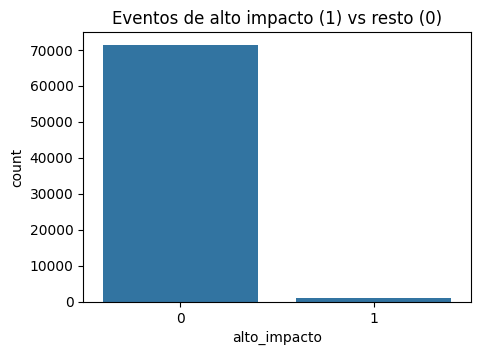

In [ ]:
conteo = df["alto_impacto"].value_counts()
print(conteo)
print()
print("Porcentaje de alto impacto:", round(df["alto_impacto"].mean() * 100, 2), "%")

print()
print("Con víctimas:", (df["victimas"] > 0).sum())
print("Con daño >= 1 millón USD:", (df["dano_total"] >= 1_000_000).sum())

plt.figure(figsize=(5, 3.5))
sns.countplot(x="alto_impacto", data=df)
plt.title("Eventos de alto impacto (1) vs resto (0)")
plt.show()

Hay 1,014 eventos de alto impacto de 72,360, es decir **1.40 %**. De esos, 779 eventos tienen víctimas y 281 tienen daño de al menos 1 millón de USD. Como se puede ver las clases están muy desbalanceadas. Un modelo que diga "ningún evento es de alto impacto" tendría 98.6 % de accuracy sin servir para nada, así que la accuracy no será una buena métrica.


## P2. Distribuciones: tipos de evento, daños y víctimas

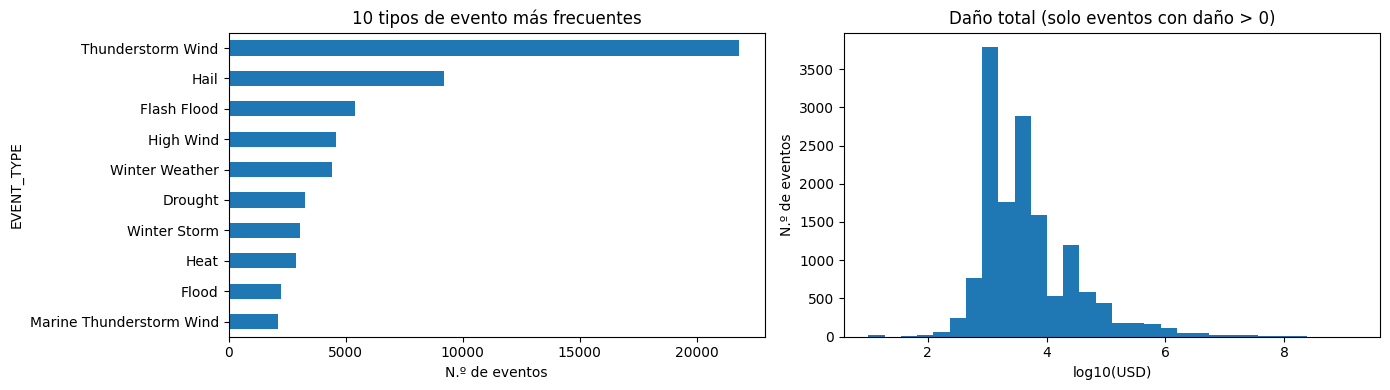

Eventos con daño > 0: 14718 de 72360
Daño total (USD) entre los eventos con daño > 0:
count    1.471800e+04
mean     3.241900e+05
std      1.371040e+07
min      1.000000e+01
25%      1.000000e+03
50%      3.000000e+03
75%      1.000000e+04
max      1.600000e+09
Name: dano_total, dtype: float64

Eventos con al menos una víctima: 779
Máximo de víctimas en un evento: 166


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df["EVENT_TYPE"].value_counts().head(10).sort_values().plot(kind="barh", ax=axes[0])
axes[0].set_title("10 tipos de evento más frecuentes")
axes[0].set_xlabel("N.º de eventos")

con_dano = df.loc[df["dano_total"] > 0, "dano_total"]
axes[1].hist(np.log10(con_dano), bins=30)
axes[1].set_title("Daño total (solo eventos con daño > 0)")
axes[1].set_xlabel("log10(USD)")
axes[1].set_ylabel("N.º de eventos")

plt.tight_layout()
plt.show()

print("Eventos con daño > 0:", len(con_dano), "de", len(df))
print("Daño total (USD) entre los eventos con daño > 0:")
print(con_dano.describe().round(0))
print()
print("Eventos con al menos una víctima:", (df["victimas"] > 0).sum())
print("Máximo de víctimas en un evento:", df["victimas"].max())

### **Lo que muestran los datos**

* **Thunderstorm Wind** (21,807) y **Hail** (9,205) son los tipos de eventos más frecuentes, bastante por encima de los demás.

* Solo **14,718 eventos tienen algún daño registrado mayor que 0**, y la mediana del daño es de aproximadamente **3,000 USD**. En el gráfico con escala logarítmica se puede ver que los valores van desde daños de algunas decenas de dólares hasta **cientos de millones**.

* En cuanto a las víctimas, la mayoría de los eventos tienen **0 muertes o lesiones**, mientras que unos pocos llegan a tener decenas de personas afectadas. El máximo registrado es de **166 víctimas en un solo evento**.

### **Interpretación**

Los daños tienen una **distribución bastante sesgada**, ya que la mayoría de eventos tienen daños bajos o nulos, mientras que unos pocos concentran cantidades muy grandes.

Por eso, consideramos que tiene más sentido plantear el problema como una **clasificación de alto impacto (sí/no)** en lugar de intentar predecir directamente el monto exacto del daño. Además, los valores extremos no deberían eliminarse simplemente por ser muy altos, porque justamente podrían representar los eventos que queremos identificar como de alto impacto.


## P3. Alto impacto según el tipo de evento

                  n_eventos  n_alto_impacto   tasa
EVENT_TYPE                                        
Wildfire                350              79  0.226
Lightning               288              57  0.198
Tornado                1591             128  0.080
Heat                   2864             105  0.037
Excessive Heat         1439              45  0.031
Dust Storm              320              10  0.031
Lake-Effect Snow        163               4  0.025
Flash Flood            5393             118  0.022
Cold/Wind Chill        1065              20  0.019
Dense Fog               632              11  0.017


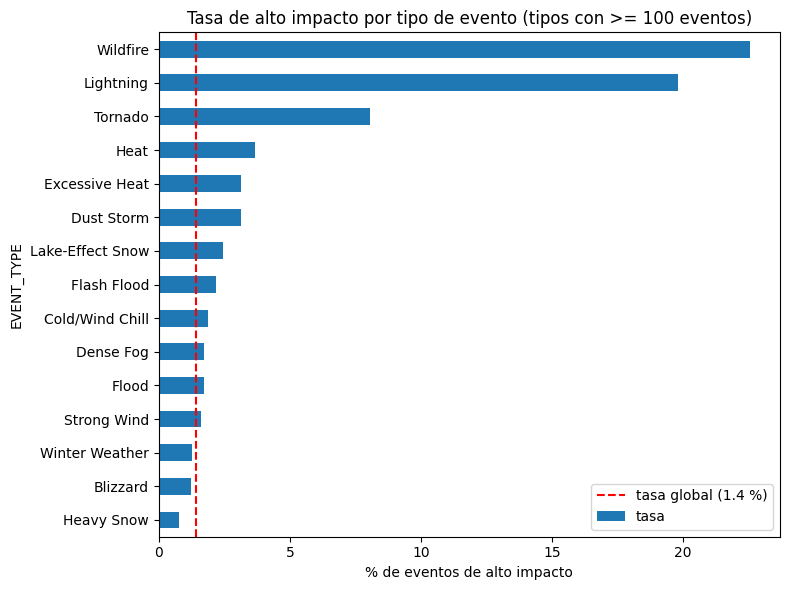

In [ ]:
por_tipo = df.groupby("EVENT_TYPE")["alto_impacto"].agg(["count", "sum", "mean"])
por_tipo.columns = ["n_eventos", "n_alto_impacto", "tasa"]
por_tipo = por_tipo[por_tipo["n_eventos"] >= 100]      # evitamos tipos con muy pocos casos

print(por_tipo.sort_values("tasa", ascending=False).head(10).round(3))

plt.figure(figsize=(8, 6))
(por_tipo["tasa"].sort_values().tail(15) * 100).plot(kind="barh")
plt.axvline(df["alto_impacto"].mean() * 100, color="red", linestyle="--", label="tasa global (1.4 %)")
plt.xlabel("% de eventos de alto impacto")
plt.title("Tasa de alto impacto por tipo de evento (tipos con >= 100 eventos)")
plt.legend()
plt.tight_layout()
plt.show()

**Lo que muestran los datos.** La tasa cambia muchísimo según el tipo: *Wildfire* 22.6 % (350 eventos),
*Lightning* 19.8 % (288) y *Tornado* 8.0 % (1,591) están muy por encima de la tasa global (1.4 %).
En el otro extremo, *Hail* tiene 0.18 % (17 de 9,205) y *Marine Thunderstorm Wind* 0.05 %.

**Interpretación del grupo.** El tipo de evento parece una de las variables más informativas.
Un modelo que solo use el tipo ya podría ser un baseline razonable, y el modelo "real" tendrá que
superarlo para justificarse. Ojo: los tipos con mucha tasa pero pocos eventos (como *Wildfire*) aportan menos positivos en total
que tipos frecuentes con tasa baja (como *Thunderstorm Wind*).

## P4. Alto impacto según el mes

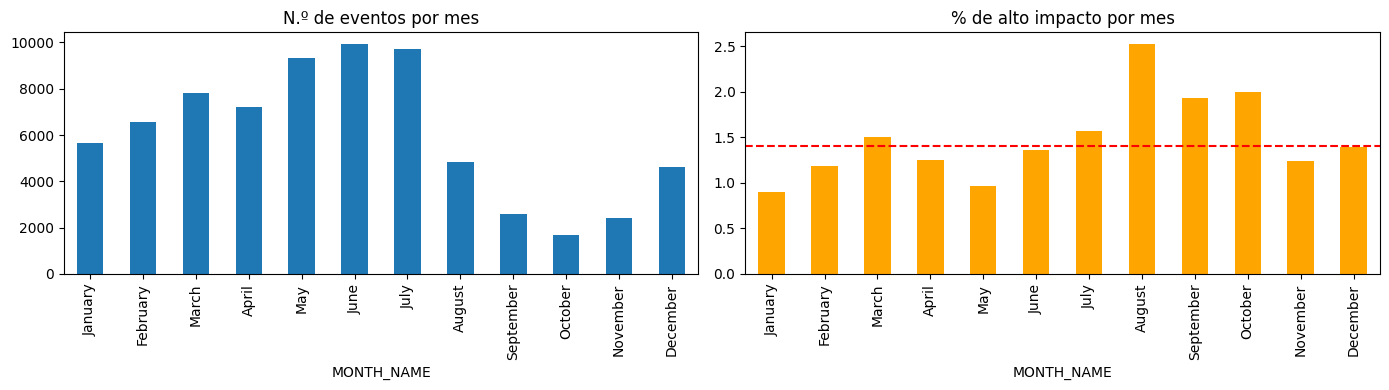

In [ ]:
orden_meses = ["January", "February", "March", "April", "May", "June", "July",
               "August", "September", "October", "November", "December"]

por_mes = df.groupby("MONTH_NAME")["alto_impacto"].agg(["count", "mean"]).reindex(orden_meses)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
por_mes["count"].plot(kind="bar", ax=axes[0])
axes[0].set_title("N.º de eventos por mes")

(por_mes["mean"] * 100).plot(kind="bar", ax=axes[1], color="orange")
axes[1].axhline(df["alto_impacto"].mean() * 100, color="red", linestyle="--")
axes[1].set_title("% de alto impacto por mes")

plt.tight_layout()
plt.show()

### **Lo que muestran los datos**

La mayor cantidad de eventos ocurre entre mayo y julio, con más de 9,300 eventos por mes.

Sin embargo, tener más eventos no significa necesariamente tener más eventos de alto impacto. La tasa de alto impacto es mayor en **agosto (2.5 %)** y **octubre (2.0 %)**, mientras que es menor en **enero (0.9 %)** y **mayo (1.0 %)**.

### **Interpretación**

El mes parece tener una relación más bien **débil con el objetivo**, ya que las diferencias en la tasa de alto impacto son relativamente pequeñas comparadas con las diferencias que vimos entre los tipos de evento.

También es posible que parte de esta relación se deba a los tipos de eventos que son más frecuentes en cada mes. Por ejemplo, algunos fenómenos pueden concentrarse en determinadas épocas del año, pero esto no lo hemos comprobado todavía.


## P5. Alto impacto según quién reporta el evento (`SOURCE`)

                           n_eventos  n_alto_impacto   tasa
SOURCE                                                     
County Official                  321             133  0.414
Park/Forest Service              337              56  0.166
NWS Storm Survey                1772             144  0.081
Broadcast Media                 2045             140  0.068
Fire Department/Rescue           952              42  0.044
Emergency Manager               6785             215  0.032
Law Enforcement                 2202              64  0.029
Official NWS Observations        827              11  0.013
State Official                  1287              13  0.010
Department of Highways          2267              21  0.009
Amateur Radio                    783               6  0.008
River/Stream Gage                676               5  0.007
911 Call Center                 4839              25  0.005
NWS Employee                     998               5  0.005
Social Media                    1003    

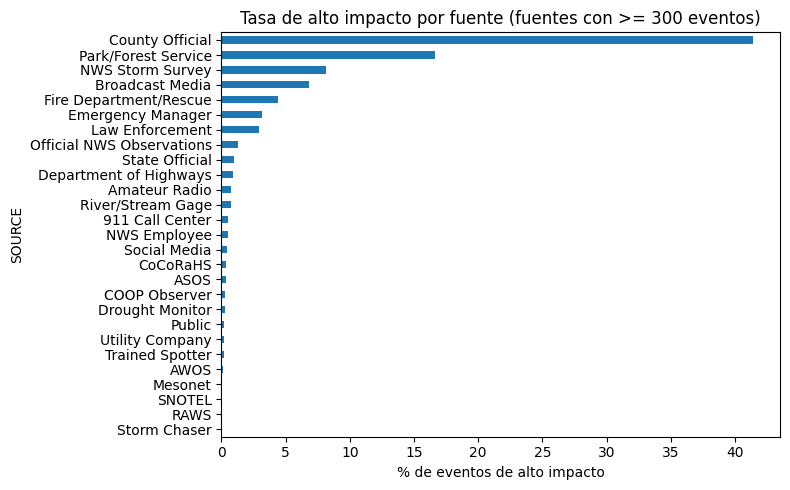

In [ ]:
por_fuente = df.groupby("SOURCE")["alto_impacto"].agg(["count", "sum", "mean"])
por_fuente.columns = ["n_eventos", "n_alto_impacto", "tasa"]
por_fuente = por_fuente[por_fuente["n_eventos"] >= 300].sort_values("tasa", ascending=False)

print(por_fuente.round(3))

plt.figure(figsize=(8, 5))
(por_fuente["tasa"].sort_values() * 100).plot(kind="barh")
plt.xlabel("% de eventos de alto impacto")
plt.title("Tasa de alto impacto por fuente (fuentes con >= 300 eventos)")
plt.tight_layout()
plt.show()

### **Lo que muestran los datos**

La tasa de alto impacto también cambia bastante según la fuente del reporte. **County Official** tiene una tasa de **41.4 %** (321 eventos), seguido de **Park/Forest Service** con **16.6 %**, **NWS Storm Survey** con **8.1 %** y **Broadcast Media** con **6.8 %**.

En cambio, algunas fuentes automáticas, como **RAWS**, **SNOTEL** y **Storm Chaser**, tienen una tasa de **0 %** en estos datos.

### **Interpretación**

Sin embargo, estos resultados pueden ser engañosos. Es posible que algunas fuentes, especialmente autoridades, encuestas del NWS o medios, aparezcan con mayor frecuencia **después de que ya ocurrió un evento importante o se reportaron daños o víctimas**.

Por eso, `SOURCE` podría estar relacionado con el impacto como consecuencia del evento y no como una característica que podamos conocer antes. Si usamos esta variable como predictor, el modelo podría obtener buenos resultados por una razón que no representa realmente una predicción anticipada.

Esto representa un posible problema de **data leakage**, por lo que debemos evaluarlo antes de incluir `SOURCE` en el modelo.


## P6. Diferencias entre grupos: duración e intensidad

Duración (horas) por grupo:
                count   mean  50%     max
alto_impacto                             
0             71346.0  35.63  0.1  743.98
1              1014.0  38.23  2.0  743.98

Magnitud (nudos) en Thunderstorm Wind:
                count  mean   50%    max
alto_impacto                            
0             21664.0  53.8  52.0  109.0
1               143.0  62.2  56.0  104.0


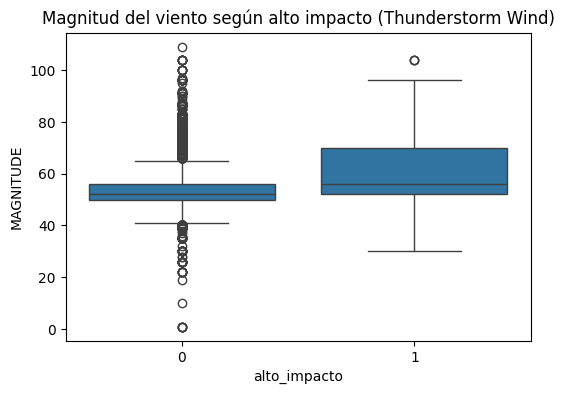

In [ ]:
inicio = pd.to_datetime(df["BEGIN_DATE_TIME"], format="%d-%b-%y %H:%M:%S", errors="coerce")
fin    = pd.to_datetime(df["END_DATE_TIME"],   format="%d-%b-%y %H:%M:%S", errors="coerce")
df["duracion_h"] = (fin - inicio).dt.total_seconds() / 3600

print("Duración (horas) por grupo:")
print(df.groupby("alto_impacto")["duracion_h"].describe()[["count", "mean", "50%", "max"]].round(2))

# La magnitud no se puede comparar entre tipos (nudos vs pulgadas), así que usamos un solo tipo
viento = df[df["EVENT_TYPE"] == "Thunderstorm Wind"]
print()
print("Magnitud (nudos) en Thunderstorm Wind:")
print(viento.groupby("alto_impacto")["MAGNITUDE"].describe()[["count", "mean", "50%", "max"]].round(1))

plt.figure(figsize=(6, 4))
sns.boxplot(x="alto_impacto", y="MAGNITUDE", data=viento)
plt.title("Magnitud del viento según alto impacto (Thunderstorm Wind)")
plt.show()

### **Lo que muestran los datos**

La duración también cambia entre los eventos normales y los de alto impacto. La duración mediana es de **0.1 horas** en los eventos normales, mientras que en los de alto impacto es de **2.0 horas**.

En **Thunderstorm Wind**, los eventos de alto impacto (143) tienen una magnitud mediana de **56 nudos**, frente a **52 nudos** en los demás eventos (21,664). Además, el promedio es de **62 nudos** frente a **54 nudos**, aunque también hay algunos valores bastante altos.

### **Interpretación**

En general, los eventos de alto impacto tienden a **durar más y presentar una mayor intensidad**, pero las distribuciones se traslapan bastante, como se puede ver en el boxplot. Por eso, la intensidad por sí sola **no parece suficiente para identificar un evento de alto impacto**.

Además, la duración depende bastante del tipo de evento. Por ejemplo, una sequía puede durar mucho más que un tornado, por lo que comparar la duración de todos los tipos de eventos directamente no es del todo limpio. Esto sugiere q


## P7. Patrones raros y anomalías

In [ ]:
print("Eventos con duración exacta 0 h:", (df["duracion_h"] == 0).sum(),
      f"({(df['duracion_h'] == 0).mean():.1%})")

print()
print("Tipos con mayor duración mediana (horas):")
print(df.groupby("EVENT_TYPE")["duracion_h"].median().sort_values(ascending=False).head(3).round(1))

print()
print("Los 5 eventos con mayor daño:")
df.nlargest(5, "dano_total")[["EVENT_TYPE", "STATE", "dano_total", "victimas"]]

Eventos con duración exacta 0 h: 27091 (37.4%)

Tipos con mayor duración mediana (horas):
EVENT_TYPE
Drought             720.0
Wildfire            124.6
Storm Surge/Tide     57.0
Name: duracion_h, dtype: float64

Los 5 eventos con mayor daño:


,EVENT_TYPE,STATE,dano_total,victimas
27385,Tornado,MISSOURI,1.600000e+09,42
58835,Flash Flood,ILLINOIS,2.300000e+08,0
65403,Flash Flood,TEXAS,2.000000e+08,61
67627,Flash Flood,ILLINOIS,2.000000e+08,0
50857,Flash Flood,TEXAS,1.050000e+08,0


In [ ]:
sin_coord = df["BEGIN_LAT"].isna()
print("Eventos sin coordenadas:", sin_coord.sum(), f"({sin_coord.mean():.1%})")
print()
print(pd.crosstab(df["CZ_TYPE"], sin_coord, normalize="index").round(3))

Eventos sin coordenadas: 28443 (39.3%)

BEGIN_LAT  False  True 
CZ_TYPE                
C          0.997  0.003
Z          0.078  0.922


### **Lo que muestran los datos**

* El **37.4 % de los eventos tiene una duración de 0 horas**, es decir, la hora de inicio y fin es la misma. En cambio, las **sequías** son los eventos que duran más, con una mediana de aproximadamente **720 horas**.

* El evento con mayor daño registrado es un **tornado en Missouri**, con aproximadamente **1,600 millones de USD** en daños y **42 víctimas**. Después aparecen varios casos de **Flash Flood** en Illinois y Texas con daños bastante altos.

* El **39.3 % de los eventos no tiene coordenadas**. Esto está relacionado con el tipo de zona: en las zonas de pronóstico (`CZ_TYPE = Z`) solo el **7.8 %** tiene coordenadas, mientras que en las zonas por condado (`CZ_TYPE = C`) las tienen casi todos (**99.7 %**).

### **Interpretación**

Los eventos con duración de 0 horas parecen corresponder a **eventos puntuales**, como un reporte de granizo, por lo que no necesariamente representan errores en los datos.

Los valores extremos de daño también tienen sentido según el tipo de evento, así que **no deberíamos eliminarlos simplemente por ser valores muy altos**, ya que justamente pueden corresponder a los eventos que queremos identificar como de alto impacto.

Por otro lado, la falta de coordenadas no parece ser aleatoria, sino que está relacionada con el tipo de zona. Por eso, si usamos latitud y longitud directamente en el modelo, podríamos terminar perdiendo una parte importante de los eventos o introduciendo algún sesgo. Tendremos que considerar esto al momento de preparar estas variables.


## Resumen del EDA

| # | Hallazgo (datos) | Decisión que condiciona |
|---|------------------|-------------------------|
| 1 | Solo 1.4 % de eventos son de alto impacto | No usar accuracy; usar recall / precisión; cuidar la separación train/test |
| 2 | Daños con cola muy larga | Clasificar en vez de predecir montos; no borrar extremos |
| 3 | El tipo de evento separa mucho las clases | Usarlo como variable clave y como baseline |
| 4 | Mes con efecto débil | Variable secundaria |
| 5 | `SOURCE` muy asociada al objetivo, pero posiblemente consecuencia del impacto | Discutir riesgo de leakage antes de usarla |
| 6 | Más duración e intensidad en eventos graves, con traslape | Usar duración y magnitud con cuidado (la magnitud depende del tipo) |
| 7 | 39 % sin coordenadas, no al azar | No depender de latitud/longitud; usar estado / tipo de zona |

# 4. Calidad y preparación de datos

##Valores faltantes

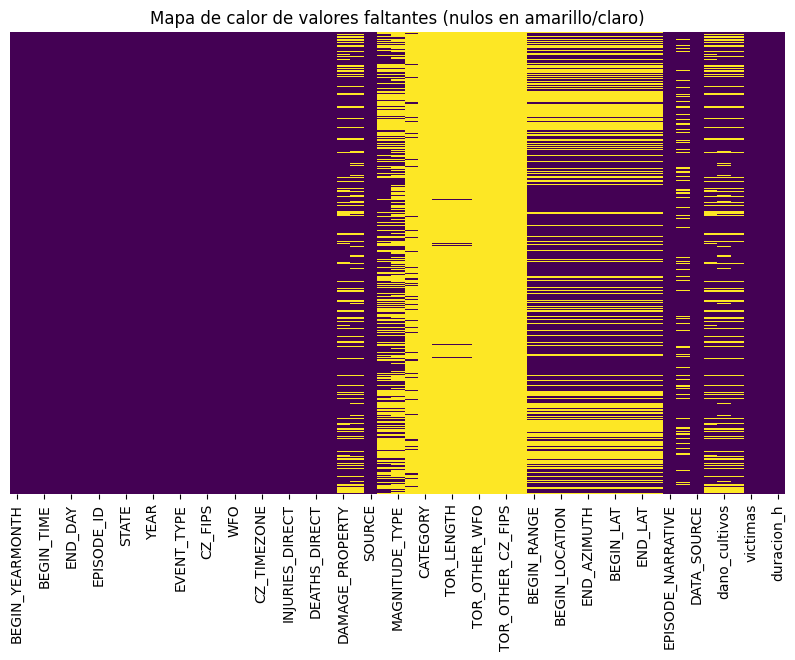

In [ ]:
#valores faltantes en heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.isna(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Mapa de calor de valores faltantes (nulos en amarillo/claro)")
plt.show()

In [ ]:
# Calcular el porcentaje de valores nulos por columna
porcentaje_nulos = (df.isna().sum() / len(df)) * 100
porcentaje_nulos = porcentaje_nulos.sort_values(ascending=False)

# Convertir a DataFrame para una visualización más limpia
porcentaje_nulos_df = porcentaje_nulos.to_frame(name="% de Nulos")
display(porcentaje_nulos_df.head(25))

,% de Nulos
CATEGORY,100.000000
TOR_OTHER_WFO,99.610282
TOR_OTHER_CZ_STATE,99.610282
TOR_OTHER_CZ_FIPS,99.610282
TOR_OTHER_CZ_NAME,99.610282
TOR_WIDTH,97.801271
TOR_LENGTH,97.801271
TOR_F_SCALE,97.801271
FLOOD_CAUSE,89.197070
MAGNITUDE_TYPE,58.898563


##Duplicados


In [ ]:
print("Filas duplicadas exactas:", df.duplicated().sum())
print("EVENT_ID repetidos:", df["EVENT_ID"].duplicated().sum())
print("Eventos únicos:", df["EVENT_ID"].nunique(), "de", len(df))

Filas duplicadas exactas: 0
EVENT_ID repetidos: 0
Eventos únicos: 72360 de 72360


In [ ]:
# ¿Hay filas que repiten TODO menos el EVENT_ID?
cols_sin_id = [c for c in df.columns if c != "EVENT_ID"]
posible_dup = df.duplicated(subset=cols_sin_id, keep="first")

print("Filas que repiten todas las columnas menos EVENT_ID:", posible_dup.sum(),
      f"({posible_dup.mean():.2%})")
print("De ellas, de alto impacto:", df.loc[posible_dup, "alto_impacto"].sum())
print()
print("Tipos de evento más repetidos:")
print(df.loc[posible_dup, "EVENT_TYPE"].value_counts().head(5))

Filas que repiten todas las columnas menos EVENT_ID: 79 (0.11%)
De ellas, de alto impacto: 0

Tipos de evento más repetidos:
EVENT_TYPE
Thunderstorm Wind    32
Hail                 13
Flash Flood          10
Winter Storm          6
Winter Weather        3
Name: count, dtype: int64


In [ ]:
# Ejemplo de pares repetidos
pares = df[df.duplicated(subset=cols_sin_id, keep=False)].sort_values(["EPISODE_ID", "BEGIN_DATE_TIME", "CZ_NAME"])
pares[["EVENT_ID", "EPISODE_ID", "EVENT_TYPE", "STATE", "CZ_NAME", "BEGIN_DATE_TIME", "MAGNITUDE"]].head(8)

,EVENT_ID,EPISODE_ID,EVENT_TYPE,STATE,CZ_NAME,BEGIN_DATE_TIME,MAGNITUDE
12390,1222372,197568,Winter Storm,MISSOURI,BATES,04-JAN-25 12:00:00,NaN
14670,1222371,197568,Winter Storm,MISSOURI,BATES,04-JAN-25 12:00:00,NaN
12389,1222370,197568,Winter Storm,MISSOURI,CASS,04-JAN-25 12:00:00,NaN
14469,1222368,197568,Winter Storm,MISSOURI,CASS,04-JAN-25 12:00:00,NaN
12020,1222152,197568,Blizzard,MISSOURI,PLATTE,05-JAN-25 03:00:00,NaN
14277,1222151,197568,Blizzard,MISSOURI,PLATTE,05-JAN-25 03:00:00,NaN
15637,1227352,198488,Strong Wind,CALIFORNIA,KAISER TO RODGERS RIDGE,13-FEB-25 12:37:00,43.0
15840,1227353,198488,Strong Wind,CALIFORNIA,KAISER TO RODGERS RIDGE,13-FEB-25 12:37:00,43.0


In [ ]:
# Los eventos de un mismo episodio comparten sistema meteorológico
por_episodio = df.groupby("EPISODE_ID").size()
print("Episodios distintos:", len(por_episodio))
print("Eventos por episodio -> mediana:", por_episodio.median(), "| máximo:", por_episodio.max())

Episodios distintos: 9846
Eventos por episodio -> mediana: 3.0 | máximo: 412


* No hay **filas duplicadas exactas** (0) ni **`EVENT_ID` repetidos**. Es decir, los 72,360 eventos tienen un identificador único.

* Sin embargo, al comparar todas las columnas **excepto `EVENT_ID`**, encontramos **79 filas (0.11 %)** que son iguales a otra fila del mismo episodio: tienen el mismo tipo de evento, condado o zona, hora y demás valores. La mayoría son *Thunderstorm Wind* (32), *Hail* (13) y *Flash Flood* (10). **Ninguna corresponde a un evento de alto impacto.**

* Los 9,846 episodios tienen una mediana de 3 eventos y un máximo de 412. Esto muestra que varios eventos pueden pertenecer al mismo sistema de tormentas.

Un duplicado exacto y un conflicto de clave no son lo mismo. En este caso no tenemos duplicados exactos, así que no eliminamos registros por ese motivo. Las 79 filas encontradas **parecen registros repetidos**, pero no podemos asegurar que realmente lo sean, ya que podrían ser reportes distintos que coincidentemente tienen los mismos valores.

Como representan solo el **0.11 %** de los datos y ninguno es de alto impacto, decidimos **marcarlos con la bandera `posible_duplicado` en lugar de eliminarlos**.

Además, como los eventos de un mismo episodio pueden ser bastante similares entre sí, al momento de separar los datos en train y test tendremos que **agrupar por `EPISODE_ID`** para evitar que eventos del mismo episodio queden en ambos conjuntos y terminen filtrando información entre ellos.



## Tipos de datos

In [ ]:
print(df.dtypes.value_counts())

revisar = ["BEGIN_DATE_TIME", "END_DATE_TIME", "BEGIN_TIME", "DAMAGE_PROPERTY", "DAMAGE_CROPS",
           "EVENT_ID", "EPISODE_ID", "STATE_FIPS", "CZ_FIPS", "YEAR", "CATEGORY"]

pd.DataFrame({
    "tipo_actual": df[revisar].dtypes.astype(str),
    "ejemplo": df[revisar].iloc[0].astype(str)
})

object     25
int64      17
float64    15
Name: count, dtype: int64


,tipo_actual,ejemplo
BEGIN_DATE_TIME,object,31-MAR-25 11:04:00
END_DATE_TIME,object,31-MAR-25 11:06:00
BEGIN_TIME,int64,1104
DAMAGE_PROPERTY,object,1.00K
DAMAGE_CROPS,object,nan
EVENT_ID,int64,1252415
EPISODE_ID,int64,201366
STATE_FIPS,int64,13
CZ_FIPS,int64,45
YEAR,int64,2025


In [ ]:
# Convertimos las fechas a datetime (columnas nuevas, no tocamos las originales)
df["inicio"] = pd.to_datetime(df["BEGIN_DATE_TIME"], format="%d-%b-%y %H:%M:%S", errors="coerce")
df["fin"]    = pd.to_datetime(df["END_DATE_TIME"],   format="%d-%b-%y %H:%M:%S", errors="coerce")

print("Fechas de inicio que no se pudieron convertir:", df["inicio"].isna().sum())
print("Fechas de fin que no se pudieron convertir:", df["fin"].isna().sum())
print("Tipo nuevo:", df["inicio"].dtype)

df[["BEGIN_DATE_TIME", "inicio", "END_DATE_TIME", "fin"]].head(3)

Fechas de inicio que no se pudieron convertir: 0
Fechas de fin que no se pudieron convertir: 0
Tipo nuevo: datetime64[ns]


,BEGIN_DATE_TIME,inicio,END_DATE_TIME,fin
0,31-MAR-25 11:04:00,2025-03-31 11:04:00,31-MAR-25 11:06:00,2025-03-31 11:06:00
1,30-MAR-25 15:52:00,2025-03-30 15:52:00,30-MAR-25 15:55:00,2025-03-30 15:55:00
2,05-JAN-25 18:00:00,2025-01-05 18:00:00,06-JAN-25 22:27:00,2025-01-06 22:27:00


In [ ]:
# Validamos la conversión de los daños que hicimos en la sección 3.0
for col, nueva in [("DAMAGE_PROPERTY", "dano_propiedad"), ("DAMAGE_CROPS", "dano_cultivos")]:
    sufijos = df[col].dropna().str[-1].value_counts()
    sin_convertir = (df[col].notna() & df[nueva].isna()).sum()
    print(f"{col}: sufijos -> {sufijos.to_dict()} | valores sin convertir: {sin_convertir}")

DAMAGE_PROPERTY: sufijos -> {'K': 55582, 'M': 259, '0': 119, 'B': 1} | valores sin convertir: 0
DAMAGE_CROPS: sufijos -> {'K': 55075, '0': 119, 'M': 20} | valores sin convertir: 0


### **Lo que muestran los datos**

Hay 25 columnas de texto (`object`), 17 enteras y 15 decimales. Los problemas de tipo que encontramos son:

| Columna | Tipo actual | Problema | Decisión |
|---------|-------------|----------|----------|
| `BEGIN_DATE_TIME`, `END_DATE_TIME` | texto | fecha escrita como `31-MAR-25 11:04:00` | convertir a `datetime` (`inicio`, `fin`) |
| `DAMAGE_PROPERTY`, `DAMAGE_CROPS` | texto | monto con sufijo K, M o B (`1.00K`) | convertir a número (ya hecho en 3.0) |
| `EVENT_ID`, `EPISODE_ID`, `STATE_FIPS`, `CZ_FIPS` | entero | son códigos, no cantidades | convertir a texto |
| `BEGIN_TIME`, `END_TIME` | entero | hora como número HHMM (1104 = 11:04) | no se usa; se trabaja con `inicio` y `fin` |
| `CATEGORY` | decimal | está vacía en todas las filas | eliminar |
| `YEAR` | entero | siempre vale 2025 | eliminar |

### **Validación**

* Las **72,360 fechas** de inicio y de fin se convirtieron sin ningún error.
* Todos los daños terminan en K, M o B, o son `"0"` (119 casos sin sufijo, que son ceros). **No quedó ningún valor sin convertir.**

# Categorías inconsistentes

In [ ]:
cols_cat = ["STATE", "EVENT_TYPE", "SOURCE", "CZ_TYPE", "MONTH_NAME", "WFO",
            "CZ_TIMEZONE", "MAGNITUDE_TYPE", "TOR_F_SCALE", "CZ_NAME"]

filas = []
for col in cols_cat:
    s = df[col].dropna().astype(str)
    normal = s.str.strip().str.upper()          # sin espacios y en mayúsculas
    filas.append({
        "columna": col,
        "categorias": s.nunique(),
        "tras_normalizar": normal.nunique(),
        "con_espacios_sobrantes": (s != s.str.strip()).sum()
    })

pd.DataFrame(filas)

,columna,categorias,tras_normalizar,con_espacios_sobrantes
0,STATE,68,68,0
1,EVENT_TYPE,48,48,0
2,SOURCE,42,42,0
3,CZ_TYPE,2,2,0
4,MONTH_NAME,12,12,0
5,WFO,123,123,0
6,CZ_TIMEZONE,11,11,0
7,MAGNITUDE_TYPE,4,4,0
8,TOR_F_SCALE,7,7,0
9,CZ_NAME,3412,3412,0


In [ ]:
# CZ_NAME: probamos quitando signos de puntuación (apóstrofes, puntos)
nombres = df["CZ_NAME"].astype(str)
sin_signos = nombres.str.upper().str.replace(r"[^A-Z0-9 ]", "", regex=True)

tabla = pd.DataFrame({"original": nombres, "sin_signos": sin_signos}).drop_duplicates()
variantes = tabla.groupby("sin_signos")["original"].nunique()
variantes = variantes[variantes > 1]

print("Nombres que se escriben de dos formas:", len(variantes))
df[df["CZ_NAME"].isin(tabla[tabla["sin_signos"].isin(variantes.index)]["original"])] \
    .groupby(["CZ_NAME", "STATE", "CZ_TYPE"]).size()

Nombres que se escriben de dos formas: 2


,,,0
CZ_NAME,STATE,CZ_TYPE,
PRINCE GEORGE'S,MARYLAND,C,35
PRINCE GEORGES,MARYLAND,Z,13
QUEEN ANNE'S,MARYLAND,C,15
QUEEN ANNES,MARYLAND,Z,10


In [ ]:
print(df["CZ_TIMEZONE"].value_counts())
print()
print("Eventos con CZ_TIMEZONE poco común:")
df[df["CZ_TIMEZONE"].isin(["EDT-4", "PDT-7", "GST10"])].groupby(["CZ_TIMEZONE", "STATE"]).size()

CZ_TIMEZONE
CST-6     35400
EST-5     24782
MST-7      8601
PST-8      2578
AST-4       454
AKST-9      253
HST-10      126
SST-11       93
GST10        34
PDT-7        30
EDT-4         9
Name: count, dtype: int64

Eventos con CZ_TIMEZONE poco común:


CZ_TIMEZONE  STATE      
EDT-4        FLORIDA         9
GST10        GUAM           33
             GUAM WATERS     1
PDT-7        CALIFORNIA     30
dtype: int64

In [ ]:
# STATE mezcla estados con zonas marítimas y lagos
zonas_no_estado = ["ATLANTIC NORTH", "ATLANTIC SOUTH", "GULF OF MEXICO", "E PACIFIC", "GULF OF ALASKA",
                   "LAKE HURON", "LAKE MICHIGAN", "LAKE SUPERIOR", "LAKE ERIE", "LAKE ONTARIO",
                   "LAKE ST CLAIR", "ST LAWRENCE R", "GUAM WATERS"]

df["es_zona_marina"] = df["STATE"].isin(zonas_no_estado).astype(int)

print("Valores de STATE:", df["STATE"].nunique())
print("Eventos en zonas marítimas o lagos:", df["es_zona_marina"].sum())
print()
print(df[df["es_zona_marina"] == 1]["STATE"].value_counts().head(5))

Valores de STATE: 68
Eventos en zonas marítimas o lagos: 2410

STATE
ATLANTIC NORTH    763
GULF OF MEXICO    654
ATLANTIC SOUTH    596
LAKE MICHIGAN     154
LAKE SUPERIOR      82
Name: count, dtype: int64


In [ ]:
# Tipos de evento con muy pocos casos
conteo_tipos = df["EVENT_TYPE"].value_counts()
pocos = conteo_tipos[conteo_tipos < 50]

print(len(pocos), "tipos con menos de 50 eventos; en total suman", pocos.sum(), "eventos")
pocos

15 tipos con menos de 50 eventos; en total suman 158 eventos


,count
EVENT_TYPE,
Avalanche,34
Marine Hail,25
Marine Tropical Storm,18
Sneakerwave,15
Sleet,13
Freezing Fog,11
Tropical Storm,10
Tsunami,10
Marine Strong Wind,6


* En las 10 columnas categóricas revisadas **no encontramos espacios sobrantes ni diferencias entre mayúsculas y minúsculas**. Al normalizarlas, la cantidad de categorías se mantiene igual.

* En `CZ_NAME` sí encontramos **2 condados que aparecen escritos de dos formas diferentes**, todos en Maryland. Por ejemplo, *PRINCE GEORGE'S* (tipo condado, 35 eventos) y *PRINCE GEORGES* (tipo zona, 13), y también *QUEEN ANNE'S* (15) y *QUEEN ANNES* (10). En ambos casos se trata del mismo lugar, solo que una versión tiene apóstrofe y la otra no.

* `CZ_TIMEZONE` tiene 11 valores. La mayoría siguen el formato `CST-6`, pero también aparecen 30 eventos de California con `PDT-7` y 9 de Florida con `EDT-4`, correspondientes al horario de verano. Además, `GST10` (Guam) aparece sin guion.

* `STATE` tiene 68 valores, pero **13 de ellos no corresponden a estados**, sino a zonas marítimas y lagos, como *ATLANTIC NORTH*, *GULF OF MEXICO* y *LAKE MICHIGAN*. En total, estos casos representan **2,410 eventos**.

* Hay **15 tipos de evento con menos de 50 casos**, que en conjunto representan 158 eventos. Por ejemplo, *Lakeshore Flood* aparece solo 1 vez y *Seiche* 2 veces.

### **Decisión**

* `CZ_NAME`: crear `CZ_NAME_clean`, quitando los apóstrofes para que un mismo condado no aparezca como dos categorías diferentes.

* `CZ_TIMEZONE`: crear `CZ_TIMEZONE_clean`, agrupando `EDT-4` con `EST-5` y `PDT-7` con `PST-8`. `GST10` se mantiene como está porque corresponde al único huso horario de Guam. Las horas se mantienen en horario local.

* `STATE`: no se modifica, pero se crea la bandera `es_zona_marina` para identificar estos casos y evaluar más adelante si es necesario tratarlos de forma diferente.

* Los tipos de evento con pocos casos **no se agrupan todavía**. Esto se decidirá durante el modelamiento usando únicamente el conjunto de entrenamiento. Por ejemplo, podrían agruparse como `"Otros"`, pero hacerlo desde ahora podría usar información del conjunto de test.


##Outliers o valores extremos


In [ ]:
def resumen_iqr(serie, nombre):
    serie = serie.dropna()
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    iqr = q3 - q1
    lim_sup = q3 + 1.5 * iqr
    lim_inf = q1 - 1.5 * iqr
    n_out = ((serie < lim_inf) | (serie > lim_sup)).sum()
    return {"variable": nombre, "n": len(serie), "mediana": round(serie.median(), 2),
            "máximo": round(serie.max(), 2), "límite_sup": round(lim_sup, 2),
            "n_outliers": n_out, "% outliers": round(n_out / len(serie) * 100, 1)}

tornados = df[df["EVENT_TYPE"] == "Tornado"]

tabla_out = pd.DataFrame([
    resumen_iqr(df.loc[df["dano_total"] > 0, "dano_total"], "daño total USD (solo > 0)"),
    resumen_iqr(df.loc[df["victimas"] > 0, "victimas"], "víctimas (solo > 0)"),
    resumen_iqr(df["duracion_h"], "duración (horas)"),
    resumen_iqr(df.loc[df["EVENT_TYPE"] == "Thunderstorm Wind", "MAGNITUDE"], "viento Thunderstorm Wind (nudos)"),
    resumen_iqr(df.loc[df["EVENT_TYPE"] == "Hail", "MAGNITUDE"], "granizo (pulgadas)"),
    resumen_iqr(tornados["TOR_LENGTH"], "largo del tornado (millas)"),
    resumen_iqr(tornados["TOR_WIDTH"], "ancho del tornado (yardas)"),
]).set_index("variable")

tabla_out

,n,mediana,máximo,límite_sup,n_outliers,% outliers
variable,,,,,,
daño total USD (solo > 0),14718,3000.00,1.600000e+09,23500.00,2467,16.8
víctimas (solo > 0),779,1.00,1.660000e+02,3.50,108,13.9
duración (horas),72360,0.10,7.439800e+02,23.67,9522,13.2
viento Thunderstorm Wind (nudos),21807,52.00,1.090000e+02,65.00,1369,6.3
granizo (pulgadas),9205,1.00,6.000000e+00,2.25,531,5.8
largo del tornado (millas),1591,2.39,3.527000e+01,12.51,98,6.2
ancho del tornado (yardas),1591,100.00,3.000000e+03,675.00,148,9.3


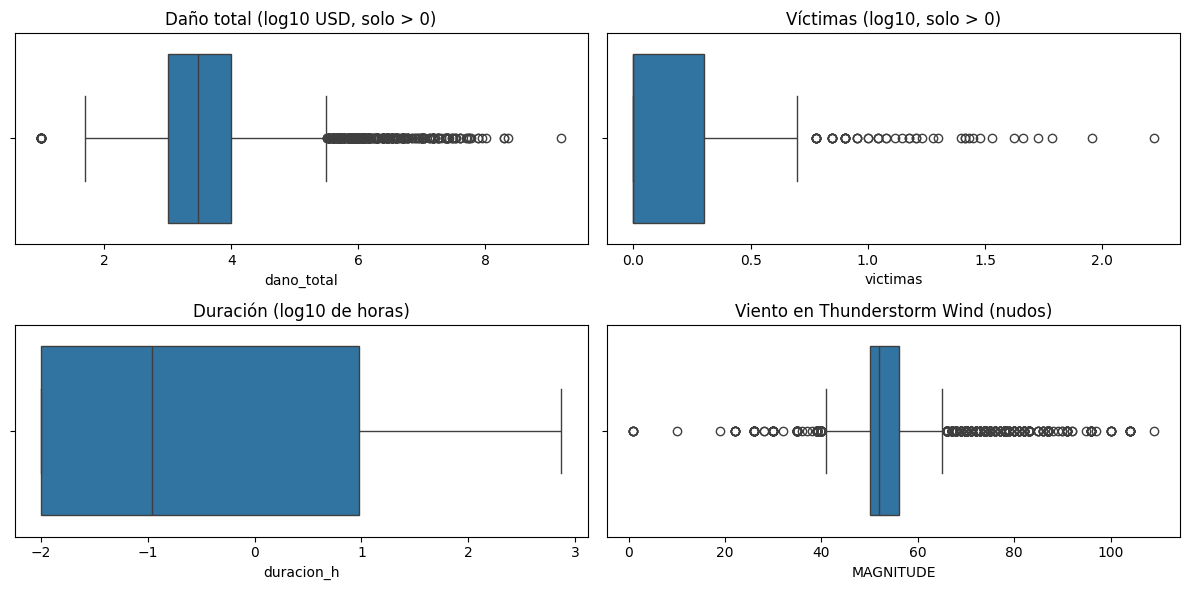

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6))

sns.boxplot(x=np.log10(df.loc[df["dano_total"] > 0, "dano_total"]), ax=axes[0, 0])
axes[0, 0].set_title("Daño total (log10 USD, solo > 0)")

sns.boxplot(x=np.log10(df.loc[df["victimas"] > 0, "victimas"]), ax=axes[0, 1])
axes[0, 1].set_title("Víctimas (log10, solo > 0)")

sns.boxplot(x=np.log10(df["duracion_h"] + 0.01), ax=axes[1, 0])
axes[1, 0].set_title("Duración (log10 de horas)")

sns.boxplot(x=df.loc[df["EVENT_TYPE"] == "Thunderstorm Wind", "MAGNITUDE"], ax=axes[1, 1])
axes[1, 1].set_title("Viento en Thunderstorm Wind (nudos)")

plt.tight_layout()
plt.show()

In [ ]:
# ¿Los extremos son errores o eventos reales? Miramos los 3 mayores daños
top = df.nlargest(3, "dano_total")
print(top[["EVENT_TYPE", "STATE", "BEGIN_DATE_TIME", "dano_total", "victimas"]])
print()
for i, fila in top.iterrows():
    print(fila["EVENT_TYPE"], "-", fila["STATE"], ":", str(fila["EVENT_NARRATIVE"])[:170], "...")
    print()

        EVENT_TYPE     STATE     BEGIN_DATE_TIME    dano_total  victimas
27385      Tornado  MISSOURI  16-MAY-25 13:42:00  1.600000e+09        42
58835  Flash Flood  ILLINOIS  17-AUG-25 01:30:00  2.300000e+08         0
65403  Flash Flood     TEXAS  04-JUL-25 03:00:00  2.000000e+08        61

Tornado - MISSOURI : The tornado was its widest and strongest in St. Louis City. After it crossed into the City, the tornado caused major tree and structural damage in and around Forest Park  ...

Flash Flood - ILLINOIS : Roughly 40,000 structures sustained flood damage around the city of Chicago. The greatest impacts were felt across the southwest side near and east of Midway Airport, but ...

Flash Flood - TEXAS : There was catastrophic and deadly flash flooding along the South Fork Guadalupe River after around ten inches of rain fell in approximately four hours. On Hwy 39 the debr ...



In [ ]:
# ¿Qué relación tienen los outliers con el alto impacto?
q1, q3 = df.loc[df["dano_total"] > 0, "dano_total"].quantile([0.25, 0.75])
lim_dano = q3 + 1.5 * (q3 - q1)

extremos_dano = df[df["dano_total"] > lim_dano]
print("Eventos con daño sobre", round(lim_dano), "USD:", len(extremos_dano))
print("De ellos, de alto impacto:", extremos_dano["alto_impacto"].sum())
print()

print("Los 5 eventos con más víctimas:")
df.nlargest(5, "victimas")[["EVENT_TYPE", "STATE", "BEGIN_DATE_TIME", "victimas"]]

Eventos con daño sobre 23500 USD: 2467
De ellos, de alto impacto: 382

Los 5 eventos con más víctimas:


,EVENT_TYPE,STATE,BEGIN_DATE_TIME,victimas
40603,Excessive Heat,NEW JERSEY,23-JUN-25 09:00:00,166
55723,Excessive Heat,MISSOURI,26-JUL-25 14:30:00,90
65403,Flash Flood,TEXAS,04-JUL-25 03:00:00,61
1834,Dust Storm,KANSAS,14-MAR-25 13:00:00,53
65607,Flash Flood,TEXAS,04-JUL-25 03:00:00,46




* Con la regla del IQR, casi todas las variables tienen valores que se consideran outliers: **2,467 eventos** tienen un daño mayor a 23,500 USD (16.8 % de los eventos que tienen daño), **108** tienen más de 3.5 víctimas, **9,522** tienen una duración de más de aproximadamente 24 horas y **1,369** presentan valores de viento fuera de lo normal dentro de *Thunderstorm Wind*.

* El porcentaje de outliers es relativamente alto porque las distribuciones son bastante asimétricas. Por ejemplo, la mediana del daño es de solo 3,000 USD, pero el máximo llega hasta **1,600 millones de USD**.

* Los valores más extremos **no parecen ser errores**. Al revisar las narrativas, el mayor daño corresponde al **tornado de St. Louis (Missouri)**, seguido por las inundaciones de **Chicago** y la **inundación del río Guadalupe en Texas**, que dejó 61 víctimas. El evento con mayor cantidad de víctimas corresponde a un caso de calor extremo en Nueva Jersey, con 166 víctimas.

* De los 2,467 eventos con daño considerado extremo, **382 son de alto impacto**. En el caso de las víctimas, los 108 outliers también son eventos de alto impacto, ya que la presencia de víctimas forma parte de la definición de esta clase.

* También encontramos valores altos en otras variables, como granizo de hasta **6 pulgadas**, viento de hasta **109 nudos** y un tornado con un ancho máximo de **3,000 yardas**. Aunque son valores extremos, siguen siendo posibles para este tipo de eventos.

### **Decisión**

**No eliminamos ni recortamos ningún outlier.** Los valores extremos corresponden a eventos reales y, justamente, son los casos que nos interesa detectar. Además, que un valor sea estadísticamente raro según el IQR no significa que sea un error.

Para el modelo trabajaremos principalmente con la variable `alto_impacto` (sí/no) en lugar de intentar predecir directamente el monto exacto del daño. Si más adelante necesitamos usar variables como daño o duración como variables numéricas, podemos aplicar una **transformación logarítmica** para reducir su asimetría en lugar de eliminar los valores extremos.


##Reglas lógicas o de negocio


In [ ]:
reglas = {
    "Fin del evento anterior al inicio": (df["fin"] < df["inicio"]).sum(),
    "Muertes o heridos negativos": (df[["DEATHS_DIRECT", "DEATHS_INDIRECT", "INJURIES_DIRECT", "INJURIES_INDIRECT"]] < 0).sum().sum(),
    "Daños negativos": (df["dano_total"] < 0).sum(),
    "Año distinto de 2025": (df["YEAR"] != 2025).sum(),
    "MONTH_NAME distinto del mes de la fecha": (df["inicio"].dt.month_name() != df["MONTH_NAME"]).sum(),
    "BEGIN_TIME distinto de la hora de la fecha": (df["inicio"].dt.hour != df["BEGIN_TIME"] // 100).sum(),
    "Escala de tornado en eventos que no son tornado": ((df["EVENT_TYPE"] != "Tornado") & df["TOR_F_SCALE"].notna()).sum(),
    "Tornados sin escala": ((df["EVENT_TYPE"] == "Tornado") & df["TOR_F_SCALE"].isna()).sum(),
    "Tornados con largo o ancho <= 0": ((df["EVENT_TYPE"] == "Tornado") & ((df["TOR_LENGTH"] <= 0) | (df["TOR_WIDTH"] <= 0))).sum(),
    "Eventos 'Marine' fuera de zona marítima": (df["EVENT_TYPE"].str.startswith("Marine") & (df["es_zona_marina"] == 0)).sum(),
    "Sequías con duración 0": ((df["EVENT_TYPE"] == "Drought") & (df["duracion_h"] == 0)).sum(),
    "Latitud o longitud fuera de rango": (df["BEGIN_LAT"].notna() & (~df["BEGIN_LAT"].between(-90, 90) | ~df["BEGIN_LON"].between(-180, 180))).sum(),
    "Coordenadas de inicio sin las de fin (o al revés)": (df["BEGIN_LAT"].isna() != df["END_LAT"].isna()).sum(),
    "Magnitud <= 0": (df["MAGNITUDE"] <= 0).sum(),
    "Thunderstorm Wind con viento < 10 nudos": ((df["EVENT_TYPE"] == "Thunderstorm Wind") & (df["MAGNITUDE"] < 10)).sum(),
    "alto_impacto mal calculado": (df["alto_impacto"] != ((df["victimas"] > 0) | (df["dano_total"].fillna(0) >= 1_000_000)).astype(int)).sum(),
}

pd.Series(reglas, name="casos que no cumplen").to_frame()

,casos que no cumplen
Fin del evento anterior al inicio,0
Muertes o heridos negativos,0
Daños negativos,0
Año distinto de 2025,0
MONTH_NAME distinto del mes de la fecha,0
BEGIN_TIME distinto de la hora de la fecha,0
Escala de tornado en eventos que no son tornado,0
Tornados sin escala,0
Tornados con largo o ancho <= 0,0
Eventos 'Marine' fuera de zona marítima,0


In [ ]:
# Casos que se ven raros pero hay que revisar
print("Eventos con víctimas pero sin dato de daño:", ((df["victimas"] > 0) & df["dano_total"].isna()).sum())
print("Daño en propiedad registrado pero cultivos vacío:", (df["DAMAGE_PROPERTY"].notna() & df["DAMAGE_CROPS"].isna()).sum())
print("Daño en cultivos registrado pero propiedad vacía:", (df["DAMAGE_CROPS"].notna() & df["DAMAGE_PROPERTY"].isna()).sum())

print()
print("Coordenadas con latitud < 15 o longitud > 0:")
df[(df["BEGIN_LAT"] < 15) | (df["BEGIN_LON"] > 0)]["STATE"].value_counts()

Eventos con víctimas pero sin dato de daño: 48
Daño en propiedad registrado pero cultivos vacío: 2219
Daño en cultivos registrado pero propiedad vacía: 1472

Coordenadas con latitud < 15 o longitud > 0:


,count
STATE,
AMERICAN SAMOA,50
GUAM,4
GUAM WATERS,1


In [ ]:
# Los 'Thunderstorm Wind' con viento muy bajo
df[(df["EVENT_TYPE"] == "Thunderstorm Wind") & (df["MAGNITUDE"] < 20)][
    ["EPISODE_ID", "STATE", "BEGIN_DATE_TIME", "MAGNITUDE", "MAGNITUDE_TYPE", "SOURCE"]]

,EPISODE_ID,STATE,BEGIN_DATE_TIME,MAGNITUDE,MAGNITUDE_TYPE,SOURCE
15583,199873,GEORGIA,16-FEB-25 04:33:00,1.0,EG,Public
15787,199873,GEORGIA,16-FEB-25 04:48:00,1.0,EG,Emergency Manager
16141,199873,GEORGIA,16-FEB-25 04:18:00,1.0,EG,Public
16145,199873,GEORGIA,16-FEB-25 04:52:00,1.0,EG,Emergency Manager
24692,203268,LOUISIANA,06-MAY-25 17:10:00,10.0,EG,Utility Company
48884,200286,ALABAMA,02-MAY-25 15:38:00,1.0,EG,Emergency Manager
57081,207191,PUERTO RICO,17-AUG-25 20:33:00,19.0,EG,911 Call Center


### **Lo que muestran los datos**

* De las 16 reglas revisadas, **15 se cumplen sin excepciones**. Esto incluye fechas coherentes, ausencia de valores negativos, año 2025, consistencia entre mes y hora con la fecha, uso de la escala de tornado solo en tornados, eventos *Marine* ubicados en zonas marítimas, sequías con duración mayor a 0, coordenadas dentro de los rangos esperados y un cálculo correcto de `alto_impacto`.

* La única regla que presenta casos es la de **viento muy bajo**. Encontramos **5 eventos de *Thunderstorm Wind* con solo 1 nudo de viento**: 4 en Georgia, pertenecientes al mismo episodio, y 1 en Alabama. Este valor resulta poco creíble para una tormenta registrada como viento dañino, por lo que podrían ser errores de captura o valores de relleno.

* También encontramos algunos casos que no incumplen ninguna regla, pero que conviene tener en cuenta:

  * **48 eventos tienen víctimas, pero no tienen registrado el daño.**
  * **2,219 eventos** tienen daño en propiedad pero no en cultivos, mientras que **1,472** tienen daño en cultivos pero no en propiedad. Como `dano_total` suma los valores ignorando los vacíos, en estos casos el total representa únicamente la parte del daño que sí está registrada.
  * Hay latitudes menores a 15 y longitudes positivas, pero corresponden a **American Samoa** (50 eventos), **Guam** (4) y **aguas de Guam** (1). Por lo tanto, son ubicaciones reales y no errores en las coordenadas.

### **Decisión**

* Los 5 eventos con viento muy bajo se **marcan con la bandera `viento_sospechoso`**, pero no se eliminan, ya que representan solo 5 de los 72,360 eventos.

* Las coordenadas de American Samoa y Guam **se mantienen tal como están**, porque corresponden a ubicaciones válidas.

* Los valores vacíos de daño se tratarán durante las transformaciones: **se rellenarán con 0 y se conservará una bandera `dano_vacio`** para indicar que originalmente no había un valor registrado. Esto implica asumir que un vacío puede tratarse como ausencia de daño, por lo que esta decisión deberá mencionarse como una **limitación del procesamiento de los datos**.


##Transformaciones realizadas.

Resumen de lo que hicimos en esta sección. Trabajamos sobre una copia (`df_limpio`) y todo lo que se modifica queda en columnas nuevas o con una bandera, para poder revisar los cambios.

In [ ]:
df_limpio = df.copy()
print("Antes -> filas:", df_limpio.shape[0], "| columnas:", df_limpio.shape[1])

# 1) Banderas (no borramos nada, solo marcamos)
df_limpio["posible_duplicado"] = posible_dup.astype(int)
df_limpio["viento_sospechoso"] = ((df_limpio["EVENT_TYPE"] == "Thunderstorm Wind") & (df_limpio["MAGNITUDE"] < 10)).astype(int)
df_limpio["dano_vacio"] = df_limpio["dano_total"].isna().astype(int)
# es_zona_marina ya se creó en la sección de categorías

# 2) Daño vacío -> 0 (con la bandera dano_vacio para saber cuáles eran vacíos)
df_limpio["dano_total_imp"] = df_limpio["dano_total"].fillna(0)

# 3) Categorías: unificar nombres y husos horarios
df_limpio["CZ_NAME_clean"] = df_limpio["CZ_NAME"].str.replace("'", "", regex=False)
df_limpio["CZ_TIMEZONE_clean"] = df_limpio["CZ_TIMEZONE"].replace({"EDT-4": "EST-5", "PDT-7": "PST-8"})

# 4) Identificadores y códigos como texto (no son cantidades)
for col in ["EVENT_ID", "EPISODE_ID", "STATE_FIPS", "CZ_FIPS"]:
    df_limpio[col] = df_limpio[col].astype(str)

# 5) Eliminar columnas vacías o con un solo valor
df_limpio = df_limpio.drop(columns=["CATEGORY", "DATA_SOURCE", "YEAR"])

print("Después -> filas:", df_limpio.shape[0], "| columnas:", df_limpio.shape[1])

Antes -> filas: 72360 | columnas: 60
Después -> filas: 72360 | columnas: 63


In [ ]:
# Validación de las transformaciones
print("Nombres de CZ_NAME antes y después:", df["CZ_NAME"].nunique(), "->", df_limpio["CZ_NAME_clean"].nunique())
print("Husos horarios antes y después:", df["CZ_TIMEZONE"].nunique(), "->", df_limpio["CZ_TIMEZONE_clean"].nunique())
print("Vacíos en dano_total_imp:", df_limpio["dano_total_imp"].isna().sum())
print("Banderas -> posible_duplicado:", df_limpio["posible_duplicado"].sum(),
      "| viento_sospechoso:", df_limpio["viento_sospechoso"].sum(),
      "| dano_vacio:", df_limpio["dano_vacio"].sum(),
      "| es_zona_marina:", df_limpio["es_zona_marina"].sum())
print("Tipo de EVENT_ID ahora:", df_limpio["EVENT_ID"].dtype)
print("Filas eliminadas:", len(df) - len(df_limpio))

Nombres de CZ_NAME antes y después: 3412 -> 3410
Husos horarios antes y después: 11 -> 9
Vacíos en dano_total_imp: 0
Banderas -> posible_duplicado: 79 | viento_sospechoso: 5 | dano_vacio: 14927 | es_zona_marina: 2410
Tipo de EVENT_ID ahora: object
Filas eliminadas: 0


### **Validación**

No se eliminó ninguna fila (siguen los 72,360 eventos). Se agregaron columnas nuevas (banderas y versiones limpias) y se quitaron 3 columnas sin información, por lo que pasamos de 60 a 63 columnas. Los vacíos de `dano_total_imp` son 0 y las banderas tienen los conteos esperados: 79 posibles duplicados, 5 vientos sospechosos, 14,927 daños vacíos y 2,410 eventos en zonas marítimas.

In [ ]:
resumen = pd.DataFrame({
    "Aspecto": ["Duplicados", "Tipos de datos (fechas)", "Tipos de datos (daños)", "Tipos de datos (códigos)",
                "Categorías (nombres)", "Categorías (husos horarios)", "Categorías (STATE)",
                "Valores faltantes (daño)", "Valores faltantes (estructurales)", "Columnas sin información",
                "Outliers", "Reglas lógicas"],
    "Problema encontrado": [
        "79 filas repiten todo menos el EVENT_ID",
        "fechas como texto (31-MAR-25 11:04:00)",
        "texto con sufijo K / M / B",
        "EVENT_ID, EPISODE_ID y FIPS guardados como números",
        "2 condados escritos de dos formas (apóstrofe)",
        "EDT-4 y PDT-7 mezclados con EST-5 y PST-8",
        "mezcla estados con zonas marítimas y lagos",
        "20.6 % del daño total vacío",
        "MAGNITUDE, TOR_* y coordenadas vacías según el tipo de evento",
        "CATEGORY vacía; DATA_SOURCE y YEAR constantes",
        "daños, víctimas y duración con colas muy largas",
        "5 eventos de viento con menos de 10 nudos"],
    "Transformación / decisión": [
        "bandera posible_duplicado; no se eliminan",
        "columnas inicio y fin (datetime)",
        "dano_propiedad, dano_cultivos y dano_total (numéricos)",
        "se convierten a texto",
        "CZ_NAME_clean (sin apóstrofes)",
        "CZ_TIMEZONE_clean (EDT -> EST, PDT -> PST)",
        "bandera es_zona_marina",
        "dano_total_imp = 0 y bandera dano_vacio",
        "no se imputan",
        "se eliminan",
        "no se eliminan ni se recortan",
        "bandera viento_sospechoso; no se eliminan"]
})
resumen

,Aspecto,Problema encontrado,Transformación / decisión
0,Duplicados,79 filas repiten todo menos el EVENT_ID,bandera posible_duplicado; no se eliminan
1,Tipos de datos (fechas),fechas como texto (31-MAR-25 11:04:00),columnas inicio y fin (datetime)
2,Tipos de datos (daños),texto con sufijo K / M / B,"dano_propiedad, dano_cultivos y dano_total (nu..."
3,Tipos de datos (códigos),"EVENT_ID, EPISODE_ID y FIPS guardados como núm...",se convierten a texto
4,Categorías (nombres),2 condados escritos de dos formas (apóstrofe),CZ_NAME_clean (sin apóstrofes)
5,Categorías (husos horarios),EDT-4 y PDT-7 mezclados con EST-5 y PST-8,"CZ_TIMEZONE_clean (EDT -> EST, PDT -> PST)"
6,Categorías (STATE),mezcla estados con zonas marítimas y lagos,bandera es_zona_marina
7,Valores faltantes (daño),20.6 % del daño total vacío,dano_total_imp = 0 y bandera dano_vacio
8,Valores faltantes (estructurales),"MAGNITUDE, TOR_* y coordenadas vacías según el...",no se imputan
9,Columnas sin información,CATEGORY vacía; DATA_SOURCE y YEAR constantes,se eliminan
